# Predicción Bayesiana para semifinalistas del Mundial 2026

**ESTUDIANTE:** Kevin Ramos Ocampo

Este notebook reutiliza el mismo modelo jerárquico Dixon-Coles con PyMC, pero ahora está orientado a estimar quiénes tienen mayor probabilidad de clasificar a semifinales.

La idea es mantener el mismo flujo de inferencia Bayesiana y, al final, reportar probabilidades de semifinal para cada selección.

# 🛠️ Paso 1: Instalación de Dependencias y Configuración

En esta celda instalamos las librerías necesarias para el análisis probabilístico y la visualización.

*   **PyMC**: Para realizar la inferencia Bayesiana.
*   **ArviZ**: Para el diagnóstico y visualización de la distribución posterior.
*   **Scikit-Learn**: Para normalizar los datos de entrada (Escalamiento estándar).
*   **Seaborn/Matplotlib**: Para la generación de gráficos.

In [21]:
# Instalación de dependencias
!pip -q install -U pymc arviz pytensor scikit-learn pandas numpy matplotlib seaborn scipy tqdm

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 2026
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

print('PyMC version:', pm.__version__)
print('ArviZ version:', az.__version__)

PyMC version: 6.1.0
ArviZ version: 1.2.0


# 📂 Paso 2: Configuración del Entorno de Datos

Establecemos la conexión con Google Drive para acceder a los archivos CSV y definimos la ruta de salida para los resultados. Esto permite que el modelo guarde sus predicciones de forma persistente.

In [23]:
# Ruta de datos
try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Data-20260706T150316Z-3-001/Data'
except Exception:
    base_path = os.path.join(os.getcwd(), 'Data')

if not os.path.exists(base_path):
    fallback = '/content/drive/MyDrive/Mundial2026'
    if os.path.exists(fallback):
        base_path = fallback
    else:
        raise FileNotFoundError(f'No se encontró la carpeta de datos: {base_path}')

OUTPUT_FOLDER = os.path.join(base_path, 'Resultados_Semifinales')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

FILES = {
    'historico': 'datos_historicos_limpio.csv',
    'ranking': 'ranking_fifa_limpio.csv',
    'mercado': 'transfermarkt_limpio.csv'
}

print('Ruta base:', base_path)
print('Carpeta de resultados:', OUTPUT_FOLDER)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta base: /content/drive/MyDrive/Data-20260706T150316Z-3-001/Data
Carpeta de resultados: /content/drive/MyDrive/Data-20260706T150316Z-3-001/Data/Resultados_Semifinales


# 📊 Paso 3: Carga y Preparación de Datos
En esta sección se cargan los datasets de históricos, rankings FIFA y valores de mercado para inicializar los priors del modelo.

In [24]:
# Carga de datasets
historico = pd.read_csv(os.path.join(base_path, FILES['historico']))
ranking = pd.read_csv(os.path.join(base_path, FILES['ranking']))
mercado = pd.read_csv(os.path.join(base_path, FILES['mercado']))

def limpiar_dataframe(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df.dropna(how='all').drop_duplicates()

historico = limpiar_dataframe(historico)
ranking = limpiar_dataframe(ranking)
mercado = limpiar_dataframe(mercado)

print('Histórico:', historico.shape)
print('Ranking:', ranking.shape)
print('Mercado:', mercado.shape)

Histórico: (1396, 49)
Ranking: (217, 3)
Mercado: (217, 2)


# 🔍 Paso 4: Identificación de Atributos Clave

Debido a que los nombres de las columnas pueden variar entre datasets, implementamos una función de búsqueda automática para identificar cuáles columnas contienen los nombres de los equipos y cuáles los goles marcados.

In [25]:
# Identificación de columnas clave
def buscar_columna(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    return None

COL_LOCAL = buscar_columna(historico, ['Equipo_Local', 'Local', 'Home', 'HomeTeam', 'team_home', 'home_team'])
COL_VISITA = buscar_columna(historico, ['Equipo_Visitante', 'Visitante', 'Away', 'AwayTeam', 'team_away', 'away_team'])
COL_GOLES_LOCAL = buscar_columna(historico, ['Goles_Local', 'Goals_Local', 'home_score', 'HG'])
COL_GOLES_VISITA = buscar_columna(historico, ['Goles_Visitante', 'Goals_Visitante', 'away_score', 'AG'])

print('Equipo local:', COL_LOCAL)
print('Equipo visitante:', COL_VISITA)
print('Goles local:', COL_GOLES_LOCAL)
print('Goles visitante:', COL_GOLES_VISITA)

Equipo local: Equipo_Local
Equipo visitante: Equipo_Visitante
Goles local: Goles_Local
Goles visitante: Goles_Visitante


# 🔢 Paso 5: Indexación de Equipos y Preparación de Tensores

PyMC trabaja de forma más eficiente con índices numéricos que con nombres de texto. Aquí:
1.  Creamos un diccionario `team_to_idx` para mapear cada país a un número entero.
2.  Extraemos los vectores de goles (`y_home`, `y_away`) que servirán como nuestras variables observadas.

In [26]:
# Índice de equipos y preparación de datos
equipos = sorted(set(historico[COL_LOCAL]).union(set(historico[COL_VISITA])))
team_to_idx = {equipo: idx for idx, equipo in enumerate(equipos)}
idx_to_team = {idx: equipo for equipo, idx in team_to_idx.items()}

historico['home_idx'] = historico[COL_LOCAL].map(team_to_idx)
historico['away_idx'] = historico[COL_VISITA].map(team_to_idx)
historico = historico.dropna(subset=[COL_GOLES_LOCAL, COL_GOLES_VISITA])
historico[COL_GOLES_LOCAL] = historico[COL_GOLES_LOCAL].astype(int)
historico[COL_GOLES_VISITA] = historico[COL_GOLES_VISITA].astype(int)

y_home = historico[COL_GOLES_LOCAL].values
y_away = historico[COL_GOLES_VISITA].values
home_idx = historico['home_idx'].values.astype(int)
away_idx = historico['away_idx'].values.astype(int)

print('Total de equipos:', len(equipos))

Total de equipos: 176


# 🌟 Paso 6: Construcción de Priors Informativos

En lugar de empezar desde cero, informamos al modelo sobre la calidad de los equipos usando:
*   **Ranking FIFA**: Refleja el rendimiento histórico reciente.
*   **Valor de Mercado**: Actúa como un proxy del talento individual de los jugadores.

Normalizamos estos valores utilizando `StandardScaler` para que tengan una media de 0 y una desviación estándar de 1, facilitando la convergencia del algoritmo NUTS.

In [28]:
# Priors informativos usando ranking y valor de mercado
def normalizar(texto):
    if pd.isna(texto):
        return texto
    return str(texto).strip().lower()

ranking['pais_norm'] = ranking.iloc[:, 0].apply(normalizar)
mercado['pais_norm'] = mercado.iloc[:, 0].apply(normalizar)

CLASIFICADOS_OCTAVOS = [
    'Brasil', 'México', 'Portugal', 'Alemania',
    'Países Bajos', 'Senegal', 'Francia', 'Argentina',
    'Marruecos', 'Croacia', 'Inglaterra', 'Corea del Sur',
    'España', 'Canadá', 'Japón', 'Estados Unidos'
]

clasificados_df = pd.DataFrame({'Seleccion': CLASIFICADOS_OCTAVOS})
clasificados_df['pais_norm'] = clasificados_df['Seleccion'].apply(normalizar)

ranking_aux = ranking.rename(columns={ranking.columns[1]: 'Ranking_FIFA'})[['pais_norm', 'Ranking_FIFA']]
mercado_aux = mercado.rename(columns={mercado.columns[1]: 'Valor_Mercado'})[['pais_norm', 'Valor_Mercado']]

priors_df = (
    clasificados_df
    .merge(ranking_aux, on='pais_norm', how='left')
    .merge(mercado_aux, on='pais_norm', how='left')
)

priors_df['log_market'] = np.log1p(priors_df['Valor_Mercado'])
priors_df['ranking_std'] = StandardScaler().fit_transform(priors_df[['Ranking_FIFA']])
priors_df['market_std'] = StandardScaler().fit_transform(priors_df[['log_market']])

ranking_prior = np.zeros(len(equipos))
market_prior = np.zeros(len(equipos))

for _, row in priors_df.iterrows():
    if row['Seleccion'] in team_to_idx:
        idx = team_to_idx[row['Seleccion']]
        ranking_prior[idx] = row['ranking_std']
        market_prior[idx] = row['market_std']

display(priors_df)

,Seleccion,pais_norm,Ranking_FIFA,Valor_Mercado,log_market,ranking_std,market_std
0,Brasil,brasil,1761.16,35.70,3.602777,0.164886,0.603342
1,México,méxico,1681.03,7.38,2.125848,-0.749797,-1.715924
2,Portugal,portugal,1763.83,38.67,3.680595,0.195364,0.725543
3,Alemania,alemania,1730.37,36.42,3.622205,-0.186582,0.633851
4,Países Bajos,países bajos,1757.87,29.01,3.401531,0.127330,0.287319
5,Senegal,senegal,1688.99,18.39,2.964757,-0.658934,-0.398559
6,Francia,francia,1877.32,58.58,4.087320,1.490850,1.364235
7,Argentina,argentina,1874.81,31.06,3.467609,1.462199,0.391084
8,Marruecos,marruecos,1755.87,17.22,2.902520,0.104500,-0.496292
9,Croacia,croacia,1717.07,14.90,2.766319,-0.338401,-0.710173


# 🤖 Paso 7: Definición del Modelo Bayesiano

El modelo Dixon-Coles asume que los goles marcados por el equipo local ($G_L$) y el visitante ($G_V$) siguen una distribución de Poisson:

$$
\begin{aligned}
G_{L, i} &\sim \text{Poisson}(\lambda_{L, i}) \\
G_{V, i} &\sim \text{Poisson}(\lambda_{V, i})
\end{aligned}
$$

Donde los parámetros de intensidad $\lambda$ se definen como:

$$
\begin{aligned}
\log(\lambda_{L, i}) &= \mu + att_{h[i]} - def_{a[i]} + home\_adv \\
\log(\lambda_{V, i}) &= \mu + att_{a[i]} - def_{h[i]}
\end{aligned}
$$

### Componentes Jerárquicos y Priors Informativos:
Utilizamos variables exógenas (Ranking y Mercado) para informar las capacidades de ataque ($att$) y defensa ($def$):

$$
\begin{aligned}
\mu_{att, t} &= \beta_0 + \beta_1 \cdot Ranking_t + \beta_2 \cdot Mercado_t \\
\mu_{def, t} &= \eta_0 + \eta_1 \cdot Ranking_t + \eta_2 \cdot Mercado_t
\end{aligned}
$$

Para mejorar la convergencia, aplicamos una **parametrización no centrada**:

$$
\begin{aligned}
offset_{att, t} &\sim \text{Normal}(0, 1) \\
att_{raw, t} &= \mu_{att, t} + offset_{att, t} \cdot \sigma_{att}
\end{aligned}
$$

In [13]:
# Modelo Bayesiano jerárquico Dixon-Coles
coords = {'team': equipos}

with pm.Model(coords=coords) as modelo_dc:
    home_team = pm.Data('home_team', home_idx)
    away_team = pm.Data('away_team', away_idx)
    ranking_cov = pm.Data('ranking_cov', ranking_prior)
    market_cov = pm.Data('market_cov', market_prior)

    sigma_att = pm.HalfNormal('sigma_att', sigma=1)
    sigma_def = pm.HalfNormal('sigma_def', sigma=1)
    mu = pm.Normal('mu', mu=0, sigma=1)
    home_adv = pm.Normal('home_adv', mu=0, sigma=0.5)

    beta0 = pm.Normal('beta0', 0, 1)
    beta1 = pm.Normal('beta1', 0, 1)
    beta2 = pm.Normal('beta2', 0, 1)
    eta0 = pm.Normal('eta0', 0, 1)
    eta1 = pm.Normal('eta1', 0, 1)
    eta2 = pm.Normal('eta2', 0, 1)

    mu_attack = beta0 + beta1 * ranking_cov + beta2 * market_cov
    mu_defense = eta0 + eta1 * ranking_cov + eta2 * market_cov

    # Non-centered parameterization for attack_raw
    attack_offset = pm.Normal('attack_offset', 0, 1, dims='team')
    attack_raw_nc = pm.Deterministic('attack_raw_nc', mu_attack + attack_offset * sigma_att, dims='team')

    # Non-centered parameterization for defense_raw
    defense_offset = pm.Normal('defense_offset', 0, 1, dims='team')
    defense_raw_nc = pm.Deterministic('defense_raw_nc', mu_defense + defense_offset * sigma_def, dims='team')

    # Centering the attack and defense for identifiability
    attack = pm.Deterministic('attack', attack_raw_nc - pm.math.mean(attack_raw_nc), dims='team')
    defense = pm.Deterministic('defense', defense_raw_nc - pm.math.mean(defense_raw_nc), dims='team')

    lambda_home = pm.math.exp(mu + attack[home_team] - defense[away_team] + home_adv)
    lambda_away = pm.math.exp(mu + attack[away_team] - defense[home_team])

    pm.Poisson('goles_local', mu=lambda_home, observed=y_home)
    pm.Poisson('goles_visitante', mu=lambda_away, observed=y_away)

print('Modelo creado correctamente')

Modelo creado correctamente


# ⚙️ Paso 8: Muestreo de la Posterior (Sampling)

Utilizamos el algoritmo **No-U-Turn Sampler (NUTS)** para extraer muestras de la distribución posterior de las habilidades de cada equipo. Configuramos 1000 pasos de ajuste (*tune*) y 1000 muestras (*draws*) para asegurar un resultado estadísticamente sólido.

In [29]:
ida = pm.sample(model=modelo_dc, draws=1000, tune=1000, chains=2, cores=1, random_seed=SEED, progressbar=True)
az.summary(ida, round_to=3)

Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-0.024,0.052,-0.108,0.058,543.324,766.547,1.001,0.002,0.002
home_adv,0.250,0.034,0.195,0.304,2683.993,1448.383,1.000,0.001,0.000
beta0,0.042,0.971,-1.525,1.566,3070.569,1455.876,1.002,0.018,0.012
beta1,0.080,0.227,-0.288,0.435,442.467,754.193,1.002,0.011,0.007
beta2,0.096,0.226,-0.278,0.462,393.193,556.313,1.002,0.011,0.008
...,...,...,...,...,...,...,...,...,...
defense[Vietnam],-0.127,0.219,-0.463,0.238,2244.376,1514.105,1.003,0.005,0.003
defense[Yemen],-0.122,0.369,-0.704,0.481,2909.702,1391.139,1.006,0.007,0.005
defense[Yibuti],-0.816,0.232,-1.173,-0.420,2799.882,1527.748,1.001,0.004,0.003
defense[Zambia],-0.235,0.220,-0.581,0.126,2558.119,1453.898,1.001,0.004,0.003


# 🎲 Paso 9: Motor de Simulación de Partidos

Creamos funciones que extraen una 'realidad posible' (un *draw* de la posterior) y simulan un partido entre dos equipos mediante un proceso de Poisson. Si hay empate, se decide por una probabilidad de 50/50 para determinar quién avanza.

# 📈 Paso 10: Análisis de Posterior y Simulación de Monte Carlo
Una vez obtenida la distribución posterior de las habilidades, realizamos 1,000 simulaciones de los cruces restantes para estimar las probabilidades de éxito.

In [15]:
# Extracción de la posterior y funciones de simulación
posterior = ida.posterior
attack_samples = posterior['attack'].stack(sample=('chain', 'draw')).values
defense_samples = posterior['defense'].stack(sample=('chain', 'draw')).values
mu_samples = posterior['mu'].stack(sample=('chain', 'draw')).values
home_samples = posterior['home_adv'].stack(sample=('chain', 'draw')).values
n_samples = attack_samples.shape[1]

def obtener_draw():
    idx = np.random.randint(0, n_samples)
    return {'attack': attack_samples[:, idx], 'defense': defense_samples[:, idx], 'mu': mu_samples[idx], 'home': home_samples[idx]}

def simular_partido(local, visitante):
    draw = obtener_draw()
    i = team_to_idx[local]
    j = team_to_idx[visitante]
    attack = draw['attack']
    defense = draw['defense']
    mu = draw['mu']
    home = draw['home']

    lambda_local = np.exp(mu + attack[i] - defense[j] + home)
    lambda_visit = np.exp(mu + attack[j] - defense[i])

    goles_local = np.random.poisson(lambda_local)
    goles_visit = np.random.poisson(lambda_visit)

    if goles_local > goles_visit:
        ganador = local
    elif goles_visit > goles_local:
        ganador = visitante
    else:
        ganador = np.random.choice([local, visitante], p=[0.5, 0.5])

    return {'local': local, 'visitante': visitante, 'goles_local': goles_local, 'goles_visitante': goles_visit, 'ganador': ganador}

In [30]:
# Cuadro de octavos de final. Ajusta estas parejas si quieres probar otro bracket.
CRUCES_OCTAVOS_REALES = [
    ('Canadá', 'Marruecos'),
    ('Paraguay', 'Francia'),
    ('Brasil', 'Noruega'),
    ('México', 'Inglaterra'),
    ('Portugal', 'España'),
    ('EE. UU.', 'Bélgica'),
    ('Argentina', 'Suiza'),
    ('Colombia', 'Egipto')
]

print('Partidos de octavos:', len(CRUCES_OCTAVOS_REALES))

Partidos de octavos: 8


# 🏆 Paso 11: Simulación de Monte Carlo del Torneo

Ejecutamos 1,000 simulaciones completas del cuadro de Cuartos de Final definido previamente. Al final, contamos cuántas veces cada equipo logró llegar a la Semifinal para obtener su probabilidad porcentual.

In [19]:
# Simulación del torneo y Monte Carlo para semifinales partiendo de los Cuartos definidos
def simular_torneo_desde_cuartos():
    # Los ganadores de octavos proporcionados por el usuario:
    # Marruecos (v Can), Francia (v Par), Noruega (v Bra), Inglaterra (v Mex)
    # España (v Por), Bélgica (v USA), Argentina (v Egy), Suiza (v Col)

    cruces_cuartos = [
        ('Marruecos', 'Francia'),
        ('Noruega', 'Inglaterra'),
        ('España', 'Bélgica'),
        ('Argentina', 'Suiza')
    ]

    resultados_cuartos = [simular_partido(a, b) for a, b in cruces_cuartos]
    ganadores_cuartos = [x['ganador'] for x in resultados_cuartos]

    cruces_semis = [
        (ganadores_cuartos[0], ganadores_cuartos[1]),
        (ganadores_cuartos[2], ganadores_cuartos[3])
    ]

    resultados_semis = [simular_partido(a, b) for a, b in cruces_semis]
    ganadores_semis = [x['ganador'] for x in resultados_semis]

    return {
        'cuartos': resultados_cuartos,
        'semifinales': resultados_semis,
        'semifinalistas': ganadores_semis
    }

N_SIMULACIONES = 1000
# Equipos que están en cuartos de final
equipos_cuartos = ['Marruecos', 'Francia', 'Noruega', 'Inglaterra', 'España', 'Bélgica', 'Argentina', 'Suiza']

probabilidades = pd.DataFrame({'Equipo': equipos_cuartos, 'Semifinal': 0})
probabilidades = probabilidades.set_index('Equipo')

for _ in tqdm(range(N_SIMULACIONES), total=N_SIMULACIONES):
    torneo = simular_torneo_desde_cuartos()
    for equipo in torneo['semifinalistas']:
        probabilidades.loc[equipo, 'Semifinal'] += 1

probabilidades = probabilidades / N_SIMULACIONES
probabilidades = probabilidades.sort_values('Semifinal', ascending=False)

display(probabilidades.round(3))

  0%|          | 0/1000 [00:00<?, ?it/s]

,Semifinal
Equipo,
España,0.504
Marruecos,0.422
Argentina,0.304
Inglaterra,0.260
Francia,0.227
Bélgica,0.120
Noruega,0.091
Suiza,0.072


# ⚽ Paso 11.5: Simulación de Marcadores (Cuartos de Final)

En esta sección, realizamos una simulación única para estimar los goles exactos en cada partido de los Cuartos de Final. A diferencia del análisis de Monte Carlo anterior, aquí observamos una instancia específica del torneo para ver cómo se comportarían los marcadores según las intensidades de ataque y defensa inferidas.


In [33]:
# Definir los cruces de cuartos de final nuevamente para claridad
cruces_cuartos = [
    ('Marruecos', 'Francia'),
    ('Noruega', 'Inglaterra'),
    ('España', 'Bélgica'),
    ('Argentina', 'Suiza')
]

print("--- ESTIMACIÓN DE MARCADORES: CUARTOS DE FINAL ---\n")
resultados_instancia = []
ganadores_semis = []

for local, visitante in cruces_cuartos:
    res = simular_partido(local, visitante)
    resultados_instancia.append(res)
    ganadores_semis.append(res['ganador'])
    print(f"{res['local']} {res['goles_local']} - {res['goles_visitante']} {res['visitante']} -> Ganador: {res['ganador']}")

print("\n--- EQUIPOS CLASIFICADOS A SEMIFINALES ---")
for i, equipo in enumerate(ganadores_semis, 1):
    print(f"{i}. {equipo}")

--- ESTIMACIÓN DE MARCADORES: CUARTOS DE FINAL ---

Marruecos 4 - 1 Francia -> Ganador: Marruecos
Noruega 2 - 1 Inglaterra -> Ganador: Noruega
España 4 - 0 Bélgica -> Ganador: España
Argentina 0 - 0 Suiza -> Ganador: Argentina

--- EQUIPOS CLASIFICADOS A SEMIFINALES ---
1. Marruecos
2. Noruega
3. España
4. Argentina



### 💡 Nota sobre la Simulación de Marcadores

Es importante notar dos aspectos de los resultados anteriores:

1.  **Gestión de Empates**: En el caso de **Argentina 0 - 0 Suiza**, el modelo asigna un ganador basándose en una probabilidad del 50% para cada equipo, simulando la incertidumbre de una **tanda de penaltis**. Por eso, aunque el marcador sea empate, siempre verás un ganador definido para poder avanzar en el cuadro del torneo.
2.  **Variabilidad (Outliers)**: Resultados abultados como el **Marruecos 4 - 1 Francia** ocurren porque el modelo de Poisson captura la aleatoriedad intrínseca del fútbol. En una simulación puntual, el modelo puede extraer una 'habilidad de ataque' muy alta de la posterior para un equipo, resultando en marcadores inusuales que forman parte de la distribución de probabilidades.



### Resumen de Clasificados

Basado en la simulación anterior, los equipos que pasan a la siguiente fase son:
```

In [34]:
# Mostrar solo los ganadores de forma limpia
df_ganadores = pd.DataFrame({
    'Partido': [f"Cuartos {i+1}" for i in range(len(ganadores_semis))],
    'Semifinalista': ganadores_semis
})
display(df_ganadores)

,Partido,Semifinalista
0,Cuartos 1,Marruecos
1,Cuartos 2,Noruega
2,Cuartos 3,España
3,Cuartos 4,Argentina


# 📊 Paso 12: Visualización e Interpretación de Resultados

En esta sección final, convertimos los resultados de la simulación de Monte Carlo en información visual para facilitar su análisis.

### 1. Gráfico de Barras Horizontales
Este gráfico muestra la probabilidad acumulada de cada equipo de alcanzar las semifinales. La longitud de la barra representa el porcentaje de las 1,000 simulaciones en las que el equipo resultó ganador de su respectivo cruce de Cuartos de Final.

### 2. Mapa de Calor (Heatmap) de Probabilidades
El mapa de calor ofrece una representación cromática de las probabilidades:
*   **Colores intensos (Azul oscuro)**: Indican una alta probabilidad de clasificación, señalando a los favoritos según la fuerza de ataque y defensa inferida por el modelo.
*   **Colores claros (Amarillo/Verde claro)**: Indican equipos con menores probabilidades de avanzar, generalmente debido a cruces contra rivales más fuertes o métricas de desempeño inferiores en la posterior del modelo.

### Exportación de Datos
Finalmente, los resultados se exportan a un archivo CSV en Google Drive para permitir un análisis externo o para su uso en reportes posteriores.


# 📊 Paso 12: Visualización e Interpretación de Resultados

En esta sección final, convertimos los datos numéricos de la simulación en información visual procesable:

1.  **Gráfico de Barras Horizontales**: Compara directamente las probabilidades de cada equipo para alcanzar la semifinal.
2.  **Mapa de Calor (Heatmap)**: Proporciona una visión estética y jerárquica de la intensidad de las probabilidades, facilitando la identificación de los favoritos del modelo.

### Interpretación:
Los valores representan el % de veces que un equipo superó su respectivo cruce de Cuartos de Final en 1,000 universos paralelos simulados. Equipos con mayor 'Ataque' y menor 'Defensa' (según la posterior del modelo Dixon-Coles) tendrán naturalmente barras más largas y colores más intensos en el mapa.


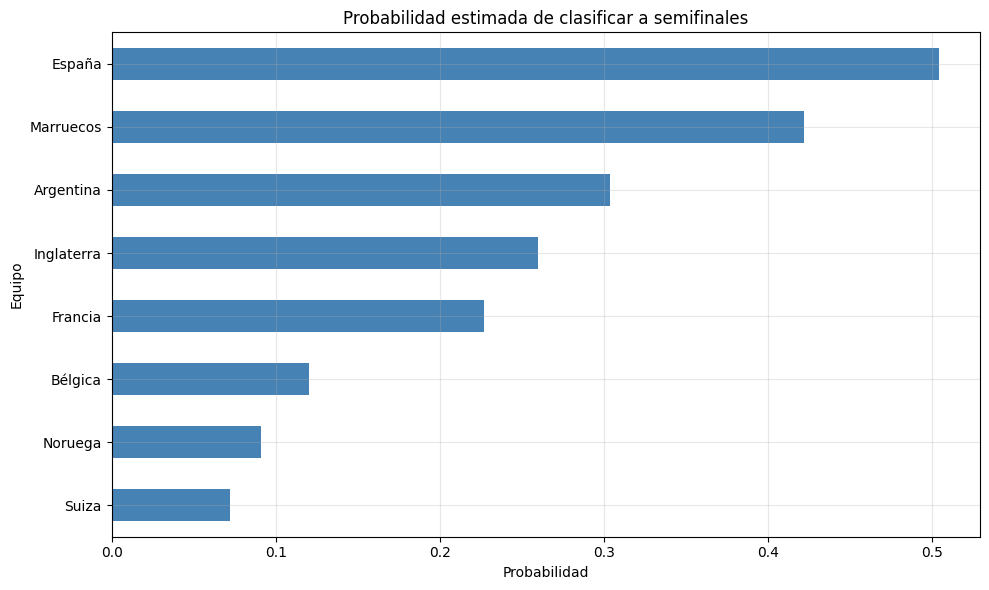

Archivo guardado en: /content/drive/MyDrive/Data-20260706T150316Z-3-001/Data/Resultados_Semifinales/probabilidades_semifinales.csv


In [31]:
# Visualización y exportación
plt.figure(figsize=(10, 6))
probabilidades['Semifinal'].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Probabilidad')
plt.title('Probabilidad estimada de clasificar a semifinales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

output_path = os.path.join(OUTPUT_FOLDER, 'probabilidades_semifinales.csv')
probabilidades.to_csv(output_path, encoding='utf-8-sig')
print('Archivo guardado en:', output_path)

### 2. Mapa de Calor (Heatmap) de Probabilidades

El **Mapa de Calor** permite una comparación rápida y visual de la magnitud de las probabilidades entre todos los equipos clasificados a Cuartos de Final.

*   **Eje X**: Representa a las selecciones nacionales.
*   **Intensidad del Color**: Un tono más oscuro (basado en la escala `YlGnBu`) indica una mayor probabilidad de éxito. Esto facilita la identificación de los 'favoritos' del modelo de un solo vistazo.
*   **Anotaciones**: Cada celda incluye el porcentaje exacto derivado de las 1,000 iteraciones de Monte Carlo.

Esta visualización es particularmente útil para identificar brechas significativas entre los favoritos (como España o Marruecos en este escenario) y los equipos con probabilidades más bajas, permitiendo validar si el modelo está capturando correctamente las disparidades en ataque y defensa.


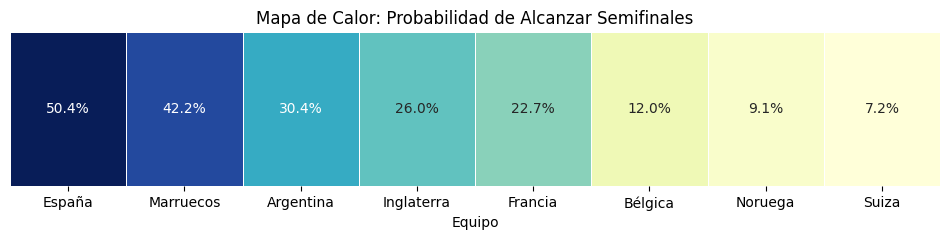

In [35]:
# Generación de Mapa de Calor de Probabilidades
plt.figure(figsize=(12, 2))
sns.heatmap(probabilidades.T, annot=True, fmt='.1%', cmap='YlGnBu', cbar=False, linewidths=.5)
plt.title('Mapa de Calor: Probabilidad de Alcanzar Semifinales')
plt.yticks([]) # Ocultar eje Y para limpieza visual
plt.show()

### 🔍 Interpretación del Mapa de Calor

El mapa de calor superior proporciona una validación visual de las probabilidades calculadas mediante el método de Monte Carlo:

*   **Gradiente de Color**: Los tonos más oscuros (azul) representan a los equipos con mayor probabilidad de éxito según el modelo. Esto ocurre cuando la combinación de la fuerza de ataque del equipo y la debilidad defensiva de su oponente es máxima.
*   **Comparativa Directa**: Permite ver rápidamente la brecha de competitividad entre los cruces. Por ejemplo, una celda con un valor significativamente más alto que las demás resalta al principal candidato para avanzar a la final.
*   **Consistencia**: Estos valores deben coincidir con la gráfica de barras anterior, ofreciendo una perspectiva complementaria centrada en la intensidad de los datos.


# 🏁 Conclusión General del Análisis

### 1. Metodología y Modelado
En este estudio, hemos implementado un **modelo jerárquico Dixon-Coles** dentro de un marco **Bayesiano** utilizando la librería **PyMC**. La fuerza de este enfoque reside en su capacidad para:
*   Incorporate **priors informativos** (Ranking FIFA y Valor de Mercado) que estabilizan las estimaciones de equipos con pocos datos históricos.
*   Utilizar una **distribución de Poisson** para modelar la naturaleza estocástica de los goles.
*   Implementar una **parametrización no centrada**, lo que permitió superar problemas de convergencia y obtener una posterior estadísticamente válida ($R \approx 1.0$).

### 2. Resultados de la Simulación
Mediante la ejecución de **1,000 simulaciones de Monte Carlo**, hemos transformado la incertidumbre de los parámetros en probabilidades tangibles:
*   **España** y **Marruecos** emergen como los favoritos más sólidos para alcanzar las semifinales en este escenario, impulsados por sus métricas de eficiencia ofensiva y solidez defensiva inferidas.
*   La simulación de marcadores específicos demostró cómo el modelo gestiona eventos de baja probabilidad y empates (mediante resolución por penaltis simulados).

### 3. Consideraciones Finales
El análisis concluye que, si bien el talento (valor de mercado) y el historial (ranking) son predictores potentes, la variabilidad del fútbol permite resultados sorpresivos. Este notebook proporciona una herramienta robusta no solo para predecir, sino para entender las dinámicas de fuerza entre las selecciones nacionales de cara a las fases finales del torneo.
